# Probabilistic N-gram Language Model for Darija

In [30]:
import re
import os
import math
import random
import json
from collections import Counter, defaultdict

DATA_DIR    = "data"
MAX_CHARS   = 5_000_000
RANDOM_SEED = 42
LAMBDA      = 0.4

random.seed(RANDOM_SEED)

## Check Data Folder

In [31]:
print("Current working directory:", os.getcwd())
print("Data folder exists:", os.path.exists(DATA_DIR))

if os.path.exists(DATA_DIR):
    print("Files/folders inside data:")
    print(os.listdir(DATA_DIR)[:20])
else:
    print("ERROR: data folder not found.")

Current working directory: c:\Users\Administrator\Desktop\assignment3
Data folder exists: True
Files/folders inside data:
['darija-wiki', 'goud.ma', 'music-data', 'story-data', 'twitter', 'Youtube']


## Load Data

In [32]:
def load_corpus(folder_path, max_chars=MAX_CHARS):
    texts = []
    total_chars = 0

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)

            try:
                if file.lower().endswith(".txt"):
                    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                        text = f.read()

                elif file.lower().endswith(".csv"):
                    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                        text = f.read()

                elif file.lower().endswith(".json"):
                    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                        data = json.load(f)

                    if isinstance(data, list):
                        text = " ".join([str(item) for item in data])
                    elif isinstance(data, dict):
                        text = " ".join([str(value) for value in data.values()])
                    else:
                        text = str(data)

                else:
                    continue

                texts.append(text)
                total_chars += len(text)

                if total_chars >= max_chars:
                    return "\n".join(texts)[:max_chars]

            except Exception as e:
                print("Skipped:", file_path, "|", e)

    return "\n".join(texts)

raw_text = load_corpus(DATA_DIR)

print("Total characters loaded:", len(raw_text))
print(raw_text[:500])

Total characters loaded: 5000000
سيدي بداج جماعة ترابية قروية كاينة ف إقليم الحوز، جهة مراكش آسفي، ساكنين فيها 5391 واحد، على حسب لإحصاء لعام 2014.[1]
تعليم[بدل | بدل لكود]
نسبة لأمية (نّاس لّي ما كايعرفوش يقراو ولا يكتبو) : 41,6%
نسبة سّكان لّي قاريين فوق تّانوي (تانوي و جامعة): 6,3%
اقتصاد[بدل | بدل لكود]
نسبة نّاس نّشيطين (لّي يقدرو يخدمو): 43,6%
سبة لبطالة (نّاس لّي ما خدامينش و تايقلبو على خدمة): 15,2%
نسبة نّاس اللي خدامين ف دّولة (ولا لعاطلين اللي سبق ليهوم خدمو): 4,4%
نسبة نّاس اللي خدامين في لقطاع لخاص (ولا لعاطلين الل


## Clean and Tokenize Text

In [33]:
def tokenize(text):
    text = text.lower()

    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\u0600-\u06FF\s.!?]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text.split()

tokens = tokenize(raw_text)

print("Total tokens:", len(tokens))
print("First 50 tokens:")
print(tokens[:50])

Total tokens: 807092
First 50 tokens:
['سيدي', 'بداج', 'جماعة', 'ترابية', 'قروية', 'كاينة', 'ف', 'إقليم', 'الحوز،', 'جهة', 'مراكش', 'آسفي،', 'ساكنين', 'فيها', '5391', 'واحد،', 'على', 'حسب', 'لإحصاء', 'لعام', '2014.', '1', 'تعليم', 'بدل', 'بدل', 'لكود', 'نسبة', 'لأمية', 'نّاس', 'لّي', 'ما', 'كايعرفوش', 'يقراو', 'ولا', 'يكتبو', '41', '6', 'نسبة', 'سّكان', 'لّي', 'قاريين', 'فوق', 'تّانوي', 'تانوي', 'و', 'جامعة', '6', '3', 'اقتصاد', 'بدل']


## Train Test Split

In [34]:
split_index = int(len(tokens) * 0.9)

train_tokens = tokens[:split_index]
test_tokens = tokens[split_index:]

print("Training tokens:", len(train_tokens))
print("Testing tokens:", len(test_tokens))

Training tokens: 726382
Testing tokens: 80710


## Build N-grams

In [35]:
def create_ngrams(token_list, n):
    return [tuple(token_list[i:i+n]) for i in range(len(token_list) - n + 1)]

unigram_counts = Counter(create_ngrams(train_tokens, 1))
bigram_counts = Counter(create_ngrams(train_tokens, 2))
trigram_counts = Counter(create_ngrams(train_tokens, 3))

vocab = set(train_tokens)
V = len(vocab)

print("Vocabulary size:", V)
print("Unique unigrams:", len(unigram_counts))
print("Unique bigrams:", len(bigram_counts))
print("Unique trigrams:", len(trigram_counts))

Vocabulary size: 81887
Unique unigrams: 81887
Unique bigrams: 270596
Unique trigrams: 344133


## Define Probability Functions

In [36]:
def unigram_prob(word):
    return (unigram_counts[(word,)] + 1) / (len(train_tokens) + V)

def bigram_prob(w1, w2):
    return (bigram_counts[(w1, w2)] + 1) / (unigram_counts[(w1,)] + V)

def trigram_prob(w1, w2, w3):
    return (trigram_counts[(w1, w2, w3)] + 1) / (bigram_counts[(w1, w2)] + V)

## Backoff Model

In [37]:
def backoff_probability(w1, w2, w3):
    if trigram_counts[(w1, w2, w3)] > 0:
        return trigram_prob(w1, w2, w3)

    elif bigram_counts[(w2, w3)] > 0:
        return LAMBDA * bigram_prob(w2, w3)

    else:
        return (LAMBDA ** 2) * unigram_prob(w3)

## Sentence Log Probability

In [38]:
def sentence_log_probability(sentence):
    words = tokenize(sentence)

    if len(words) == 0:
        return 0

    log_prob = 0

    for i in range(len(words)):
        if i == 0:
            p = unigram_prob(words[i])
        elif i == 1:
            p = bigram_prob(words[i-1], words[i])
        else:
            p = backoff_probability(words[i-2], words[i-1], words[i])

        log_prob += math.log(p)

    return log_prob

## Evaluate Perplexity

In [39]:
def calculate_perplexity(token_list, max_tokens=1000):
    token_list = token_list[:max_tokens]

    if len(token_list) < 3:
        return None

    log_prob = 0
    count = 0

    for i in range(2, len(token_list)):
        w1, w2, w3 = token_list[i-2], token_list[i-1], token_list[i]

        if w3 not in vocab:
            continue

        p = backoff_probability(w1, w2, w3)

        if p > 0:
            log_prob += math.log(p)
            count += 1

    if count == 0:
        return None

    return math.exp(-log_prob / count)

test_perplexity = calculate_perplexity(test_tokens)

print("Trigram Backoff Perplexity:", round(test_perplexity, 2))

Trigram Backoff Perplexity: 70791.68


## Test Sample Sentences

In [40]:
examples = [
    "salam labas",
    "ana mzyan lyoum",
    "ach katdir",
    "fin ghadi"
]

for sentence in examples:
    log_p = sentence_log_probability(sentence)
    token_count = len(tokenize(sentence))

    print("Sentence:", sentence)
    print("Log Probability:", round(log_p, 2))
    print("Average Log Probability:", round(log_p / token_count, 2))
    print("-" * 40)

Sentence: salam labas
Log Probability: -23.82
Average Log Probability: -11.91
----------------------------------------
Sentence: ana mzyan lyoum
Log Probability: -39.66
Average Log Probability: -13.22
----------------------------------------
Sentence: ach katdir
Log Probability: -24.92
Average Log Probability: -12.46
----------------------------------------
Sentence: fin ghadi
Log Probability: -23.12
Average Log Probability: -11.56
----------------------------------------


## Generate Text

In [41]:
trigram_next_words = defaultdict(list)

for (w1, w2, w3), count in trigram_counts.items():
    trigram_next_words[(w1, w2)].append((w3, count))

def generate_text(max_words=20):
    start_bigram = random.choice(list(trigram_next_words.keys()))
    sentence = [start_bigram[0], start_bigram[1]]

    for _ in range(max_words - 2):
        context = (sentence[-2], sentence[-1])

        if context in trigram_next_words:
            candidates, weights = zip(*trigram_next_words[context])
            next_word = random.choices(candidates, weights=weights, k=1)[0]
        else:
            next_word = random.choice(list(vocab))

        sentence.append(next_word)

    return " ".join(sentence)

for i in range(5):
    print("Generated sentence", i + 1, ":")
    print(generate_text(15))
    print()

Generated sentence 1 :
ف لعام . 1 الناس ديال تيمور و لعسكر د أندونيسيا، اللي بقات معروفة بيها

Generated sentence 2 :
اللي ساهمات فتغييرات جدرية.نشطاء 20 فبراير ماتت.لا.الحركة لم تمت أبدا.إنها حية في الدولة. وفاعلة في

Generated sentence 3 :
جوزيف نورمان لوكاير مزيود ف 17 كلم a3 مراكش لوداية سيدي الزوين محطة ديال ليستيراحة

Generated sentence 4 :
تعليمية إسرائيلية دولية تحارب التضليل ومعاداة السامية في صفوف المارة قرب سكة ترامواي الدار البيضاء

Generated sentence 5 :
marshall islands بلمارشالية aolep n aor kin aje هي بلاد جات فلجنوب ديال إفريقيا. عندها



## Most Frequent Words

In [42]:
print("Top 20 most frequent words:")

for word, count in unigram_counts.most_common(20):
    print(word[0], ":", count)

Top 20 most frequent words:
بدل : 12142
من : 10161
ديال : 8409
و : 8119
في : 7675
اللي : 7383
ف : 7378
على : 6979
نسبة : 6285
لكود : 6102
د : 6043
1 : 5474
نّاس : 4286
لّي : 4064
ما : 3485
2 : 3447
ولا : 2785
3 : 2496
. : 2400
، : 2396


## Save Final Results

In [43]:
results = {
    "model": "Trigram n-gram language model",
    "smoothing": "Laplace smoothing",
    "backoff": "Trigram to bigram to unigram",
    "lambda": LAMBDA,
    "max_characters_used": MAX_CHARS,
    "total_tokens": len(tokens),
    "training_tokens": len(train_tokens),
    "testing_tokens": len(test_tokens),
    "vocabulary_size": V,
    "unique_unigrams": len(unigram_counts),
    "unique_bigrams": len(bigram_counts),
    "unique_trigrams": len(trigram_counts),
    "test_perplexity": test_perplexity
}

with open("ngram_model_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=4, ensure_ascii=False)

print("Results saved to ngram_model_results.json")
results

Results saved to ngram_model_results.json


{'model': 'Trigram n-gram language model',
 'smoothing': 'Laplace smoothing',
 'backoff': 'Trigram to bigram to unigram',
 'lambda': 0.4,
 'max_characters_used': 5000000,
 'total_tokens': 807092,
 'training_tokens': 726382,
 'testing_tokens': 80710,
 'vocabulary_size': 81887,
 'unique_unigrams': 81887,
 'unique_bigrams': 270596,
 'unique_trigrams': 344133,
 'test_perplexity': 70791.67632296223}

## Plot: Most Frequent Words

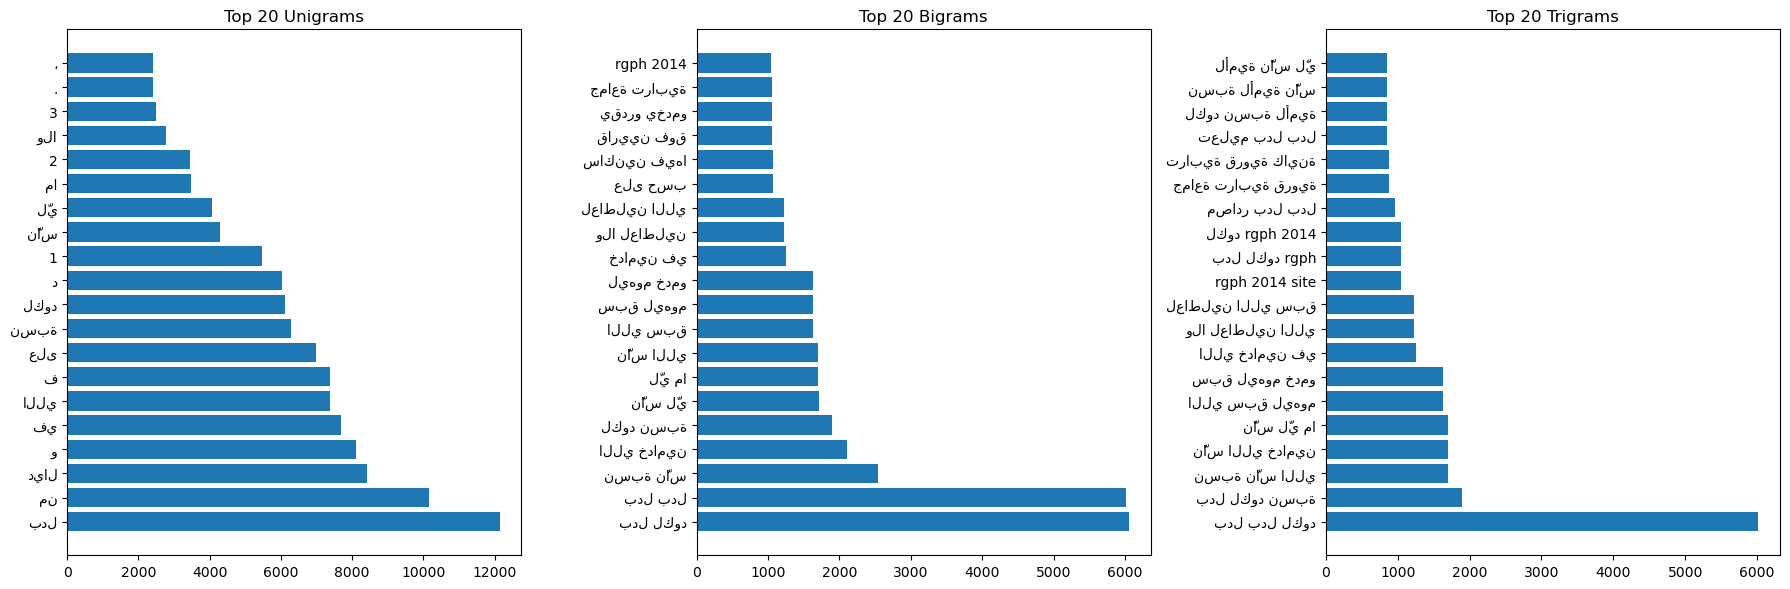

Plot saved at: c:\Users\Administrator\Desktop\assignment3\ngram_frequency_plot.png


In [47]:
import matplotlib.pyplot as plt
import os

# Top n-grams
top_uni = unigram_counts.most_common(20)
top_bi  = bigram_counts.most_common(20)
top_tri = trigram_counts.most_common(20)

# Extract labels
uni_words = [str(w[0][0]) for w in top_uni]
uni_counts = [c for _, c in top_uni]

bi_words = [" ".join(w[0]) for w in top_bi]
bi_counts = [c for _, c in top_bi]

tri_words = [" ".join(w[0]) for w in top_tri]
tri_counts = [c for _, c in top_tri]

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].barh(uni_words, uni_counts)
axes[0].set_title("Top 20 Unigrams")

axes[1].barh(bi_words, bi_counts)
axes[1].set_title("Top 20 Bigrams")

axes[2].barh(tri_words, tri_counts)
axes[2].set_title("Top 20 Trigrams")

plt.tight_layout()

# ✅ Save inside your project folder
output_path = "ngram_frequency_plot.png"
plt.savefig(output_path, dpi=300)

plt.show()

print("Plot saved at:", os.path.abspath(output_path))